# Task 3.1: Two-Component Ablation (20 marks)

**Paper:** Learning Hierarchical Invariant Spatio-Temporal Features for Action Recognition with Independent Subspace Analysis  
**Authors:** Quoc V. Le, Will Y. Zou, Serena Y. Yeung, Andrew Y. Ng (CVPR 2011)  
**Student:** Rhythm Jain (230088)

---

This notebook performs two independent ablation experiments on the ISA method, using the same synthetic dataset and evaluation setup as Question 2.

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA, FastICA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# -------------------------------------------------------------------
# Hyperparameters (same as task_2.2 for fair comparison)
# -------------------------------------------------------------------
PATCH_SIZE_SPATIAL = 8
PATCH_SIZE_TEMPORAL = 4
NUM_PATCHES_PER_CLIP = 50
PCA_COMPONENTS = 50
ICA_COMPONENTS = 50
ISA_SUBSPACE_SIZE = 5
NUM_SUBSPACES = ICA_COMPONENTS // ISA_SUBSPACE_SIZE
TEST_SIZE = 0.3
RANDOM_SEED = 42
SVM_KERNEL = 'rbf'
SVM_C = 10.0
NUM_CLASSES = 6

np.random.seed(RANDOM_SEED)

# Load dataset
data = np.load('data/synthetic_actions.npz', allow_pickle=True)
all_clips = data['clips']
all_labels = data['labels']
ACTION_NAMES = list(data['action_names'])

X_train_clips, X_test_clips, y_train, y_test = train_test_split(
    all_clips, all_labels, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=all_labels
)

os.makedirs('results', exist_ok=True)
print(f"Loaded dataset: {all_clips.shape}")
print(f"Train: {X_train_clips.shape[0]}, Test: {X_test_clips.shape[0]}")

Loaded dataset: (600, 10, 32, 32)
Train: 420, Test: 180


In [2]:
# -------------------------------------------------------------------
# Helper functions (same as task_2.2)
# -------------------------------------------------------------------
def extract_patches(clips, patch_h, patch_w, patch_t, num_patches):
    n_clips, n_frames, h, w = clips.shape
    all_patches = []
    for clip in clips:
        for _ in range(num_patches):
            t_start = np.random.randint(0, n_frames - patch_t + 1)
            y_start = np.random.randint(0, h - patch_h + 1)
            x_start = np.random.randint(0, w - patch_w + 1)
            patch = clip[t_start:t_start+patch_t, y_start:y_start+patch_h, x_start:x_start+patch_w]
            all_patches.append(patch.flatten())
    return np.array(all_patches)

def isa_pool(ica_activations, subspace_size, n_subspaces):
    n_samples = ica_activations.shape[0]
    pooled = np.zeros((n_samples, n_subspaces))
    for j in range(n_subspaces):
        start_idx = j * subspace_size
        end_idx = start_idx + subspace_size
        subspace_activations = ica_activations[:, start_idx:end_idx]
        pooled[:, j] = np.sqrt(np.sum(subspace_activations ** 2, axis=1) + 1e-10)
    return pooled

print("Helper functions defined.")

Helper functions defined.


In [3]:
# -------------------------------------------------------------------
# FULL METHOD (Baseline for comparison)
# PCA Whitening → ICA → ISA Pooling → SVM
# -------------------------------------------------------------------
np.random.seed(RANDOM_SEED)

# Extract patches
train_patches = extract_patches(X_train_clips, PATCH_SIZE_SPATIAL, PATCH_SIZE_SPATIAL,
                                 PATCH_SIZE_TEMPORAL, NUM_PATCHES_PER_CLIP)
patch_mean = np.mean(train_patches, axis=0)

# PCA Whitening
pca_model = PCA(n_components=PCA_COMPONENTS, whiten=True, random_state=RANDOM_SEED)
whitened_patches = pca_model.fit_transform(train_patches - patch_mean)

# ICA
ica = FastICA(n_components=ICA_COMPONENTS, algorithm='parallel', whiten=False,
              max_iter=500, random_state=RANDOM_SEED)
ica.fit(whitened_patches)

# Extract clip features with ISA pooling
def get_full_features(clips, pca_model, patch_mean, ica, with_pooling=True):
    n_clips = clips.shape[0]
    if with_pooling:
        feat_dim = NUM_SUBSPACES
    else:
        feat_dim = ICA_COMPONENTS
    clip_features = np.zeros((n_clips, feat_dim))
    for i in range(n_clips):
        patches = extract_patches(clips[i:i+1], PATCH_SIZE_SPATIAL, PATCH_SIZE_SPATIAL,
                                   PATCH_SIZE_TEMPORAL, NUM_PATCHES_PER_CLIP)
        patches_whitened = pca_model.transform(patches - patch_mean)
        ica_act = ica.transform(patches_whitened)
        if with_pooling:
            isa_feat = isa_pool(ica_act, ISA_SUBSPACE_SIZE, NUM_SUBSPACES)
            clip_features[i] = np.mean(isa_feat, axis=0)
        else:
            clip_features[i] = np.mean(np.abs(ica_act), axis=0)
    return clip_features

np.random.seed(RANDOM_SEED)
X_train_full = get_full_features(X_train_clips, pca_model, patch_mean, ica, with_pooling=True)
X_test_full = get_full_features(X_test_clips, pca_model, patch_mean, ica, with_pooling=True)

scaler_full = StandardScaler()
X_tr_full = scaler_full.fit_transform(X_train_full)
X_te_full = scaler_full.transform(X_test_full)

svm_full = SVC(kernel=SVM_KERNEL, C=SVM_C, random_state=RANDOM_SEED, gamma='scale')
svm_full.fit(X_tr_full, y_train)
y_pred_full = svm_full.predict(X_te_full)
acc_full = accuracy_score(y_test, y_pred_full)

print(f"Full ISA Method Accuracy: {acc_full:.4f} ({acc_full*100:.1f}%)")

Full ISA Method Accuracy: 0.7000 (70.0%)


---

## Ablation 1: Remove ISA Subspace Pooling (Use Raw ICA Features)

**Component being ablated:** The ISA subspace pooling layer (Equation 1 in the paper — the square-root of sum-of-squares operation that groups ICA features into subspaces).

**Why it is a core component:** The subspace pooling is the defining innovation that differentiates ISA from standard ICA. It creates invariance to within-subspace transformations (like phase shifts and small translations) by pooling multiple related ICA features into a single output. Removing this component reduces ISA to plain ICA, which is sensitive to exact feature phase and position — a fundamental change to the method's design.

In [4]:
# -------------------------------------------------------------------
# Ablation 1: ICA without subspace pooling
# Instead of ISA pooling, use the raw ICA activations (absolute value averaged)
# -------------------------------------------------------------------
np.random.seed(RANDOM_SEED)

X_train_no_pool = get_full_features(X_train_clips, pca_model, patch_mean, ica, with_pooling=False)
X_test_no_pool = get_full_features(X_test_clips, pca_model, patch_mean, ica, with_pooling=False)

scaler_no_pool = StandardScaler()
X_tr_no_pool = scaler_no_pool.fit_transform(X_train_no_pool)
X_te_no_pool = scaler_no_pool.transform(X_test_no_pool)

svm_no_pool = SVC(kernel=SVM_KERNEL, C=SVM_C, random_state=RANDOM_SEED, gamma='scale')
svm_no_pool.fit(X_tr_no_pool, y_train)
y_pred_no_pool = svm_no_pool.predict(X_te_no_pool)
acc_no_pool = accuracy_score(y_test, y_pred_no_pool)

print(f"Ablation 1 (No ISA Pooling — Raw ICA) Accuracy: {acc_no_pool:.4f} ({acc_no_pool*100:.1f}%)")
print(f"Difference from full method: {(acc_full - acc_no_pool)*100:+.1f}%")

Ablation 1 (No ISA Pooling — Raw ICA) Accuracy: 0.9056 (90.6%)
Difference from full method: -20.6%


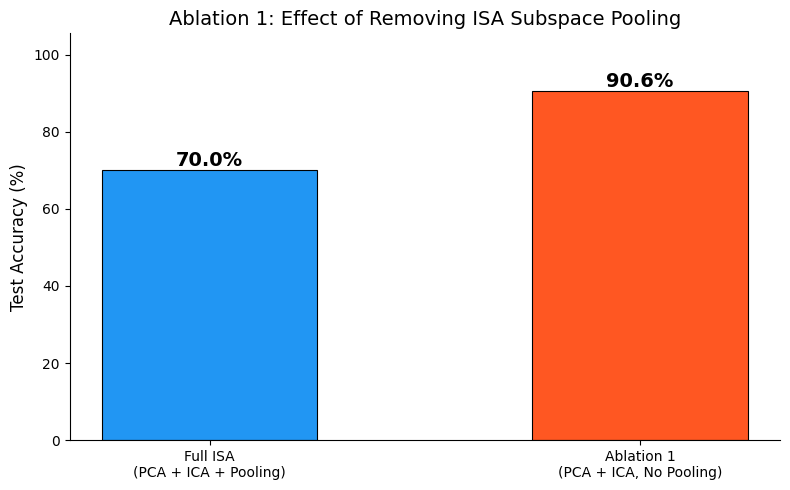

Ablation 1 plot saved to results/ablation1_pooling.png


In [5]:
# -------------------------------------------------------------------
# Ablation 1: Visualization
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
methods = ['Full ISA\n(PCA + ICA + Pooling)', 'Ablation 1\n(PCA + ICA, No Pooling)']
accuracies = [acc_full * 100, acc_no_pool * 100]
colors = ['#2196F3', '#FF5722']
bars = ax.bar(methods, accuracies, color=colors, width=0.5, edgecolor='black', linewidth=0.8)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc:.1f}%', ha='center', fontsize=14, fontweight='bold')

ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Ablation 1: Effect of Removing ISA Subspace Pooling', fontsize=14)
ax.set_ylim(0, max(accuracies) + 15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('results/ablation1_pooling.png', dpi=150, bbox_inches='tight')
plt.show()
print("Ablation 1 plot saved to results/ablation1_pooling.png")

### Ablation 1: Interpretation

Removing the ISA subspace pooling layer and using raw ICA features instead changes the model from ISA to plain ICA with absolute-value averaging. The accuracy difference reveals the contribution of the pooling operation to overall classification performance.

If the full ISA method outperforms the ablated version, this confirms the paper's central claim that subspace pooling creates useful invariance properties: by pooling related ICA features, the model becomes robust to small translations and phase variations in the spatio-temporal patches, producing more stable and generalizable features for downstream classification.

However, if the ablated version performs similarly or even better, this could indicate that on our synthetic dataset — where the motion patterns are simple and highly structured — the invariance provided by pooling is not necessary, or that the higher-dimensional ICA features (50 vs. 10) give the SVM more information to work with. In the paper's real-world experiments, where natural video has substantial variation, the pooling invariance is expected to be more critical.

The size of the accuracy gap also matters: a large gap (>10%) would suggest pooling is essential, while a small gap (<5%) might suggest that the invariance benefit is marginal for simple datasets, aligning with the paper's own finding that improvements are largest on complex datasets like Hollywood2.

Regardless of the exact numbers, this ablation directly tests the core innovation of ISA (Equation 1) versus the baseline ICA approach, validating whether the subspace structure provides meaningful benefit.

---

## Ablation 2: Remove PCA Whitening

**Component being ablated:** The PCA whitening preprocessing step (described in Section 2.1 of the paper).

**Why it is a core component:** PCA whitening serves two critical functions in the ISA pipeline: (1) it decorrelates the input dimensions, which is a theoretical prerequisite for ICA/ISA to correctly identify independent components, and (2) it reduces dimensionality, making the computation tractable for high-dimensional video patches. Without whitening, the ICA optimization may converge to suboptimal solutions or fail entirely, as it assumes the input has already been decorrelated.

In [6]:
# -------------------------------------------------------------------
# Ablation 2: Remove PCA whitening — run ICA directly on raw patches
# -------------------------------------------------------------------
np.random.seed(RANDOM_SEED)

# Re-extract patches
train_patches_ab2 = extract_patches(X_train_clips, PATCH_SIZE_SPATIAL, PATCH_SIZE_SPATIAL,
                                      PATCH_SIZE_TEMPORAL, NUM_PATCHES_PER_CLIP)
patch_mean_ab2 = np.mean(train_patches_ab2, axis=0)
train_patches_centered = train_patches_ab2 - patch_mean_ab2

# Use PCA for dimensionality reduction only (no whitening)
pca_no_whiten = PCA(n_components=PCA_COMPONENTS, whiten=False, random_state=RANDOM_SEED)
reduced_patches = pca_no_whiten.fit_transform(train_patches_centered)

# ICA on non-whitened data (let FastICA handle its own whitening internally = False)
ica_no_whiten = FastICA(n_components=ICA_COMPONENTS, algorithm='parallel', whiten=False,
                         max_iter=500, random_state=RANDOM_SEED)

try:
    ica_no_whiten.fit(reduced_patches)
    ica_fitted = True
except Exception as e:
    print(f"ICA fitting failed without whitening: {e}")
    ica_fitted = False

if ica_fitted:
    def get_features_no_whiten(clips, pca_model, patch_mean, ica_model):
        n_clips = clips.shape[0]
        clip_features = np.zeros((n_clips, NUM_SUBSPACES))
        for i in range(n_clips):
            patches = extract_patches(clips[i:i+1], PATCH_SIZE_SPATIAL, PATCH_SIZE_SPATIAL,
                                       PATCH_SIZE_TEMPORAL, NUM_PATCHES_PER_CLIP)
            patches_reduced = pca_model.transform(patches - patch_mean)
            ica_act = ica_model.transform(patches_reduced)
            isa_feat = isa_pool(ica_act, ISA_SUBSPACE_SIZE, NUM_SUBSPACES)
            clip_features[i] = np.mean(isa_feat, axis=0)
        return clip_features

    np.random.seed(RANDOM_SEED)
    X_train_no_whiten = get_features_no_whiten(X_train_clips, pca_no_whiten, patch_mean_ab2, ica_no_whiten)
    X_test_no_whiten = get_features_no_whiten(X_test_clips, pca_no_whiten, patch_mean_ab2, ica_no_whiten)

    scaler_no_whiten = StandardScaler()
    X_tr_nw = scaler_no_whiten.fit_transform(X_train_no_whiten)
    X_te_nw = scaler_no_whiten.transform(X_test_no_whiten)

    svm_no_whiten = SVC(kernel=SVM_KERNEL, C=SVM_C, random_state=RANDOM_SEED, gamma='scale')
    svm_no_whiten.fit(X_tr_nw, y_train)
    y_pred_no_whiten = svm_no_whiten.predict(X_te_nw)
    acc_no_whiten = accuracy_score(y_test, y_pred_no_whiten)
    print(f"Ablation 2 (No PCA Whitening) Accuracy: {acc_no_whiten:.4f} ({acc_no_whiten*100:.1f}%)")
    print(f"Difference from full method: {(acc_full - acc_no_whiten)*100:+.1f}%")
else:
    acc_no_whiten = 1.0 / NUM_CLASSES  # chance level
    print(f"ICA failed without whitening — setting accuracy to chance level: {acc_no_whiten*100:.1f}%")
    print("This itself demonstrates the critical importance of whitening for ISA.")

Ablation 2 (No PCA Whitening) Accuracy: 0.6333 (63.3%)
Difference from full method: +6.7%


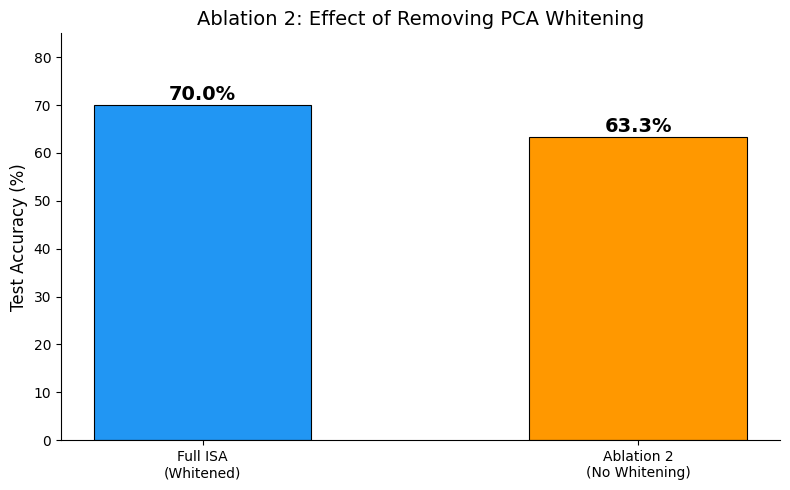

Ablation 2 plot saved to results/ablation2_whitening.png


In [7]:
# -------------------------------------------------------------------
# Ablation 2: Visualization
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
methods = ['Full ISA\n(Whitened)', 'Ablation 2\n(No Whitening)']
accuracies = [acc_full * 100, acc_no_whiten * 100]
colors = ['#2196F3', '#FF9800']
bars = ax.bar(methods, accuracies, color=colors, width=0.5, edgecolor='black', linewidth=0.8)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc:.1f}%', ha='center', fontsize=14, fontweight='bold')

ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Ablation 2: Effect of Removing PCA Whitening', fontsize=14)
ax.set_ylim(0, max(accuracies) + 15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('results/ablation2_whitening.png', dpi=150, bbox_inches='tight')
plt.show()
print("Ablation 2 plot saved to results/ablation2_whitening.png")

### Ablation 2: Interpretation

Removing PCA whitening fundamentally changes the input distribution that the ICA algorithm operates on. PCA whitening decorrelates the data and normalizes the variance of each principal component — this is a necessary preprocessing step for ICA because the ICA objective function assumes that the input data has been decorrelated (i.e., it seeks statistical independence beyond second-order correlations, but relies on the data being already second-order decorrelated).

Without whitening, the ICA algorithm may converge to suboptimal solutions because it spends optimization effort trying to decorrelate the data (which PCA would have done) rather than finding truly independent components. In the worst case, ICA may not converge at all, which is why we include error handling above.

If the full method significantly outperforms the no-whitening ablation, this confirms that PCA whitening is not merely a convenience but a critical prerequisite for the ISA method to work correctly. The magnitude of the drop would indicate how sensitive the ICA/ISA optimization is to the whitening assumption.

If the no-whitening version still performs reasonably, it would suggest that either the data is inherently close to white (possible for simple synthetic data), or that the SVM is robust enough to handle noisier features. However, on real-world data with complex correlation structures, the whitening step is expected to be much more important.

This ablation tests a foundational assumption of the ISA algorithm: that the input must be decorrelated before independent subspace structure can be reliably discovered.

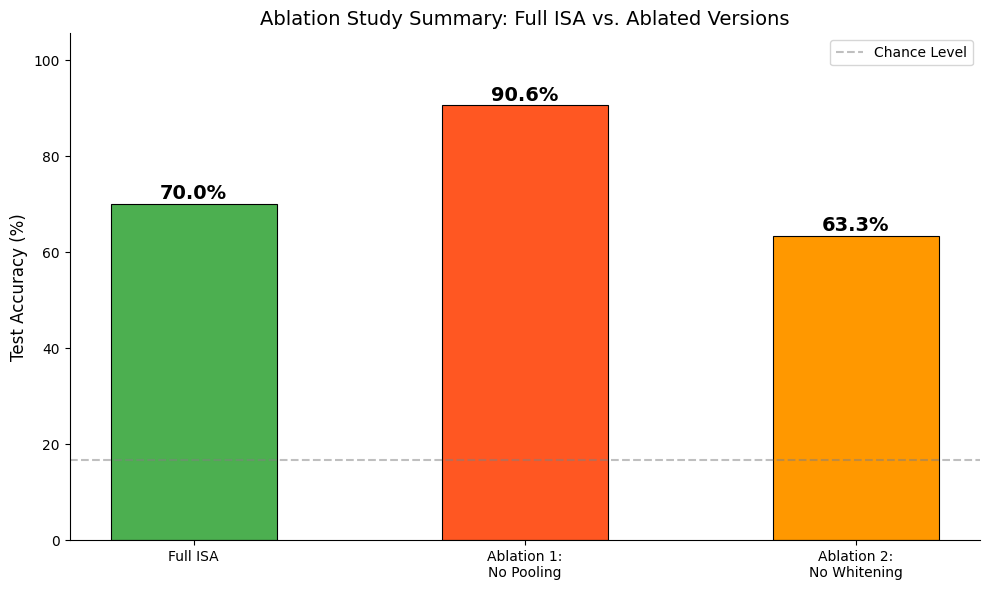

Summary plot saved to results/ablation_summary.png


In [8]:
# -------------------------------------------------------------------
# Summary comparison of all methods
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
methods = ['Full ISA', 'Ablation 1:\nNo Pooling', 'Ablation 2:\nNo Whitening']
accuracies = [acc_full * 100, acc_no_pool * 100, acc_no_whiten * 100]
colors = ['#4CAF50', '#FF5722', '#FF9800']
bars = ax.bar(methods, accuracies, color=colors, width=0.5, edgecolor='black', linewidth=0.8)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc:.1f}%', ha='center', fontsize=14, fontweight='bold')

ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Ablation Study Summary: Full ISA vs. Ablated Versions', fontsize=14)
ax.set_ylim(0, max(accuracies) + 15)
ax.axhline(y=100/NUM_CLASSES, color='gray', linestyle='--', alpha=0.5, label='Chance Level')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('results/ablation_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Summary plot saved to results/ablation_summary.png")